In [32]:
! pip install openpyxl


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import matplotlib.pyplot as plt
import pandas as pd

# Loading dataset

df -> Df ,
Or -> Orders ,
Pr -> Products ,
Sa -> Sales ,
Sh -> Shipping

In [34]:
df = pd.read_excel('Df.xlsx')
Or = pd.read_excel('Orders.xlsx')
Pr = pd.read_excel('Products.xlsx')
Sa = pd.read_excel('Sales.xlsx')
Sh = pd.read_excel('Shipping.xlsx')

In [35]:
print (df.head())
print (Or.head())
print (Pr.head())
print (Sa.head())
print (Sh.head())

         order_id           order_date            ship_date       ship_mode  \
0  CA-2011-148614           21-01-2011           26-01-2011  Standard Class   
1  CA-2011-103310  2011-10-05 00:00:00           15-05-2011  Standard Class   
2  CA-2011-118962  2011-05-08 00:00:00  2011-09-08 00:00:00  Standard Class   
3  CA-2011-118962  2011-05-08 00:00:00  2011-09-08 00:00:00  Standard Class   
4  CA-2011-156433           20-09-2011           26-09-2011  Standard Class   

   customer_name   segment       state        country market region  ...  \
0  Mark Van Huff  Consumer  California  United States     US   West  ...   
1  Greg Matthias  Consumer  California  United States     US   West  ...   
2   Chad Sievert  Consumer  California  United States     US   West  ...   
3   Chad Sievert  Consumer  California  United States     US   West  ...   
4    Erica Smith  Consumer  California  United States     US   West  ...   

          category sub_category  \
0  Office Supplies        Paper  

In [36]:
print(df.shape)
print(Or.shape)
print(Pr.shape)
print(Sa.shape)
print(Sh.shape)

(51290, 21)
(51290, 6)
(51290, 4)
(51290, 6)
(51290, 9)


# Explore the Data

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  str    
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  str    
 4   customer_name   51290 non-null  str    
 5   segment         51290 non-null  str    
 6   state           51290 non-null  str    
 7   country         51290 non-null  str    
 8   market          51290 non-null  str    
 9   region          51290 non-null  str    
 10  product_id      51290 non-null  str    
 11  category        51290 non-null  str    
 12  sub_category    51290 non-null  str    
 13  product_name    51290 non-null  str    
 14  sales           51290 non-null  int64  
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null  float64
 1

In [38]:
df.describe()

,sales,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,246.498440,3.476545,0.142908,28.641740,26.375915,2012.777208
std,487.567175,2.278766,0.212280,174.424113,57.296804,1.098931
min,0.000000,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,31.000000,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,85.000000,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,251.000000,5.000000,0.200000,36.810000,24.450000,2014.000000
max,22638.000000,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [39]:
Or.describe()

,quantity
count,51290.000000
mean,3.476545
std,2.278766
min,1.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,14.000000


In [40]:
Pr.describe()

,product_id,product_name,category,sub_category
count,51290,51290,51290,51290
unique,10292,3788,3,17
top,OFF-AR-10003651,Staples,Office Supplies,Binders
freq,35,227,31273,6152


In [41]:
Sa.describe()

,sales,quantity,profit
count,51290.000000,51290.000000,51290.000000
mean,246.498440,3.476545,28.641740
std,487.567175,2.278766,174.424113
min,0.000000,1.000000,-6599.978000
25%,31.000000,2.000000,0.000000
50%,85.000000,3.000000,9.240000
75%,251.000000,5.000000,36.810000
max,22638.000000,14.000000,8399.976000


In [42]:
Sh.describe()

,shipping_cost
count,51290.000000
mean,26.375915
std,57.296804
min,0.000000
25%,2.610000
50%,7.790000
75%,24.450000
max,933.570000


In [43]:
print(Sa.columns)
print(Pr.columns)

Index(['order_id', 'product_name', 'sales', 'quantity', 'profit',
       'product_id'],
      dtype='str')
Index(['product_id', 'product_name', 'category', 'sub_category'], dtype='str')


# Merging the tables

In [ ]:
Sales_Products = pd.merge(Sa, Pr, on='product_id', how='inner')
Sales_Shipping = pd.merge(Sa, Sh, on='order_id', how='inner')
Sales_Orders = pd.merge(Sa, Or, on='order_id', how = 'inner')


In [45]:
Sales_Products.head()

,order_id,product_name_x,sales,quantity,profit,product_id,product_name_y,category,sub_category
0,HU-2011-1380,"Eaton Note Cards, Premium",53,2,0.0,OFF-AVE-10004512,"Avery Hole Reinforcements, Economy",Office Supplies,Binders
1,HU-2011-1380,"Eaton Note Cards, Premium",53,2,0.0,OFF-AVE-10004512,"Avery Hole Reinforcements, Economy",Office Supplies,Binders
2,HU-2011-1380,"Eaton Note Cards, Premium",53,2,0.0,OFF-AVE-10004512,"Avery Hole Reinforcements, Economy",Office Supplies,Binders
3,HU-2011-1380,"Eaton Note Cards, Premium",53,2,0.0,OFF-AVE-10004512,"Avery Hole Reinforcements, Economy",Office Supplies,Binders
4,HU-2011-1380,"Eaton Note Cards, Premium",53,2,0.0,OFF-AVE-10004512,"Avery Hole Reinforcements, Economy",Office Supplies,Binders


In [48]:
Sales_Products.shape

(375312, 9)

# Group by Data

In [50]:
sales_by_category = Sales_Products.groupby('category')['sales'].sum()
print(sales_by_category)

category
Furniture          30257477
Office Supplies    36557464
Technology         19008759
Name: sales, dtype: int64


In [57]:
sales_by_region = Sales_Shipping.groupby('region')['sales'].sum()
print(sales_by_region)

region
Africa            2394963
Canada             203747
Caribbean          962633
Central           9303316
Central Asia      2298421
EMEA              2541521
East              2196743
North             3722461
North Asia        2687343
Oceania           3185585
South             5013458
Southeast Asia    2680426
West              2162965
Name: sales, dtype: int64


In [64]:
sales_by_customer = Sales_Orders.groupby('customer_name')['sales'].sum()

top10 = sales_by_customer.head(10)

print(top10)

customer_name
Aaron Bergman         85572
Aaron Hawkins         35885
Aaron Smayling        51272
Adam Bellavance       55512
Adam Hart             58183
Adam Shillingsburg    45632
Adrian Barton         50353
Adrian Hane           34176
Adrian Shami          35516
Aimee Bixby           50202
Name: sales, dtype: int64


In [68]:
profit_by_category = Sales_Products.groupby('category')['profit'].sum()
print(profit_by_category)

category
Furniture          3.419807e+06
Office Supplies    4.047849e+06
Technology         2.322299e+06
Name: profit, dtype: float64


In [74]:
shipping_cost_by_market = Sh.groupby('market')['shipping_cost'].sum().sort_values(ascending=False)
print(shipping_cost_by_market)

market
APAC      387165.11
EU        309422.35
US        238173.79
LATAM     234138.61
EMEA       88375.73
Africa     88139.47
Canada      7405.63
Name: shipping_cost, dtype: float64


In [76]:
top_10_products = Sa.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)
print(top_10_products)

product_name
Apple Smart Phone, Full Size                                86936
Cisco Smart Phone, Full Size                                76441
Motorola Smart Phone, Full Size                             73159
Nokia Smart Phone, Full Size                                71904
Canon imageCLASS 2200 Advanced Copier                       61600
Hon Executive Leather Armchair, Adjustable                  58200
Office Star Executive Leather Armchair, Adjustable          50667
Harbour Creations Executive Leather Armchair, Adjustable    50120
Samsung Smart Phone, Cordless                               48654
Nokia Smart Phone, with Caller ID                           47880
Name: sales, dtype: int64


# Bar & Pie chart for Sales & products tables

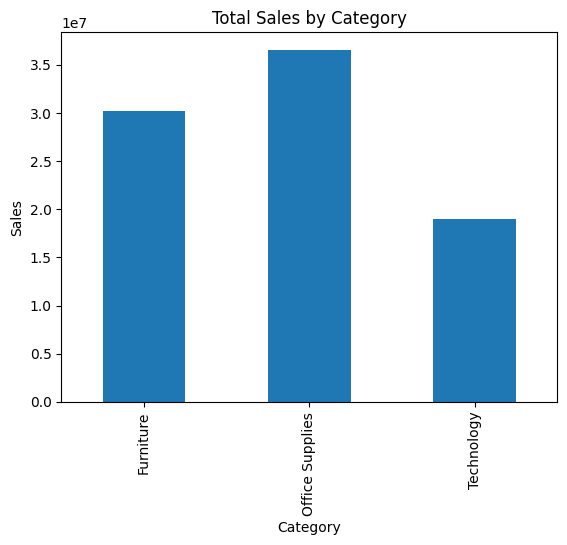

In [52]:
sales_by_category.plot(kind='bar')

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

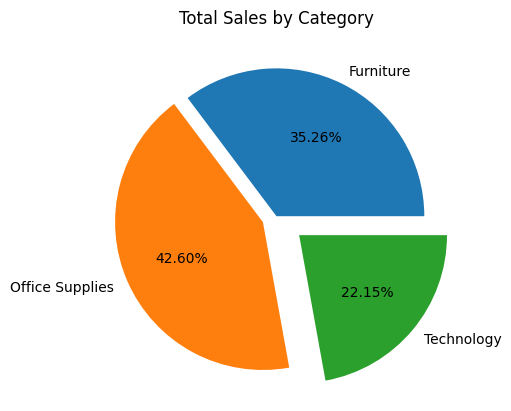

In [55]:
sales_by_category.plot(kind='pie', autopct='%1.2f%%', explode =[0, 0.1, 0.2])
plt.title('Total Sales by Category')
plt.show()

# Bar chart for Sales & Shipping

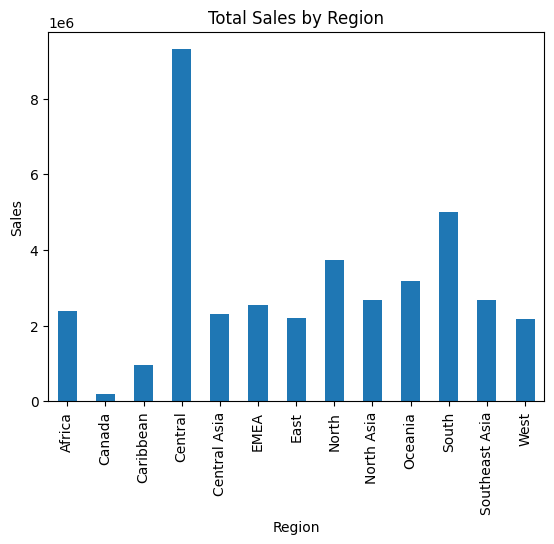

In [59]:
sales_by_region.plot(kind = 'bar')

plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()

# Bar chart for Sales & Orders 

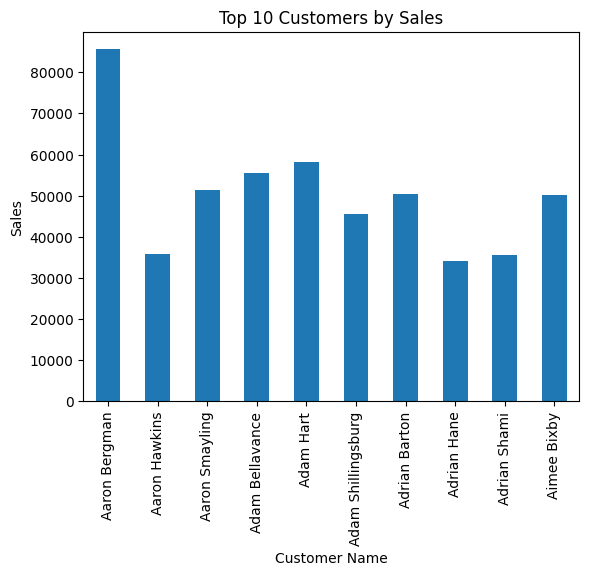

In [65]:
top10.plot(kind='bar')

plt.title('Top 10 Customers by Sales')
plt.xlabel('Customer Name')
plt.ylabel('Sales')
plt.show()

# Pie chart for Profit by category(Sales & Products)

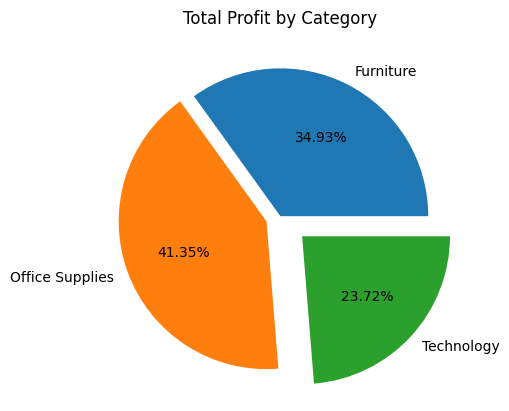

In [70]:
profit_by_category.plot(kind='pie', autopct='%1.2f%%', explode =[0,0.1,0.2])
plt.title('Total Profit by Category')
plt.show()

# Bar chart for Shipping Cost by Market (Shipping)

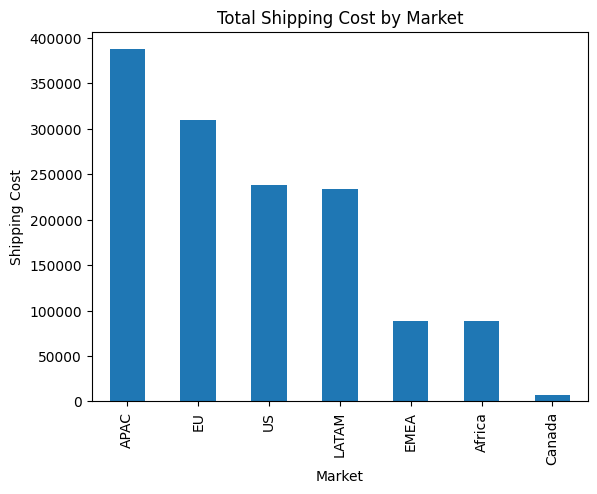

In [75]:
shipping_cost_by_market.plot(kind='bar')
plt.title('Total Shipping Cost by Market')
plt.xlabel('Market')
plt.ylabel('Shipping Cost')
plt.show()

# Top 10 Products by Sales

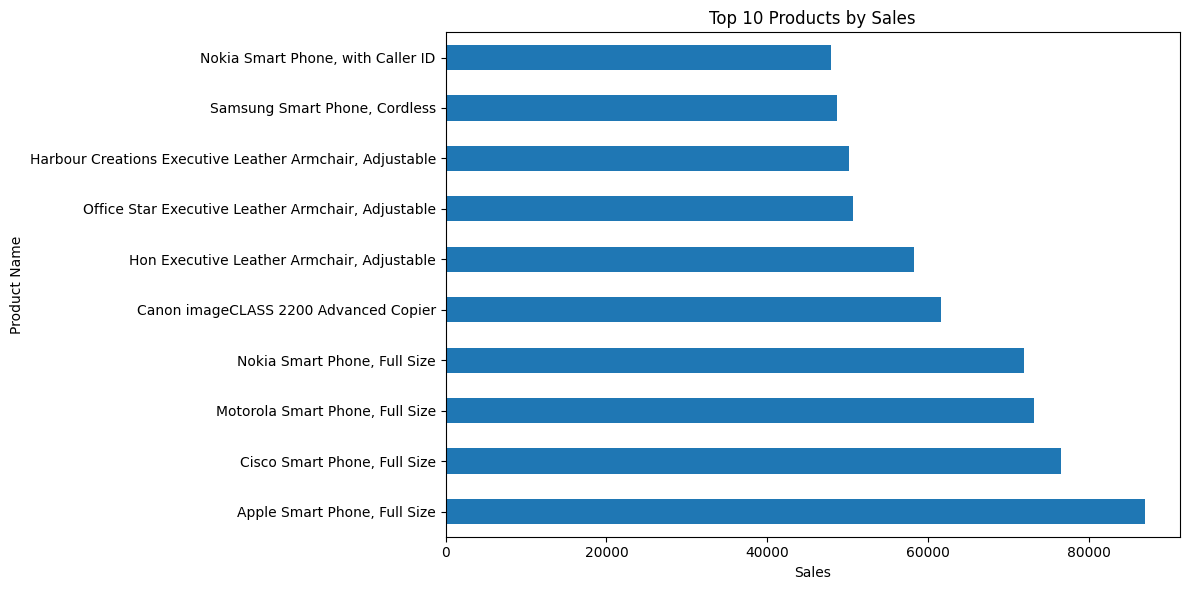

In [78]:
top_10_products.plot(kind='barh', figsize=(12,6))

plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.ylabel('Product Name')

plt.tight_layout()
plt.show()